In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [83]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [84]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [85]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [86]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    4162
0.022126       1
0.443560       1
0.022259       1
0.598641       1
            ... 
0.063253       1
0.007494       1
0.113382       1
0.010312       1
0.048601       1
Name: count, Length: 2412, dtype: int64


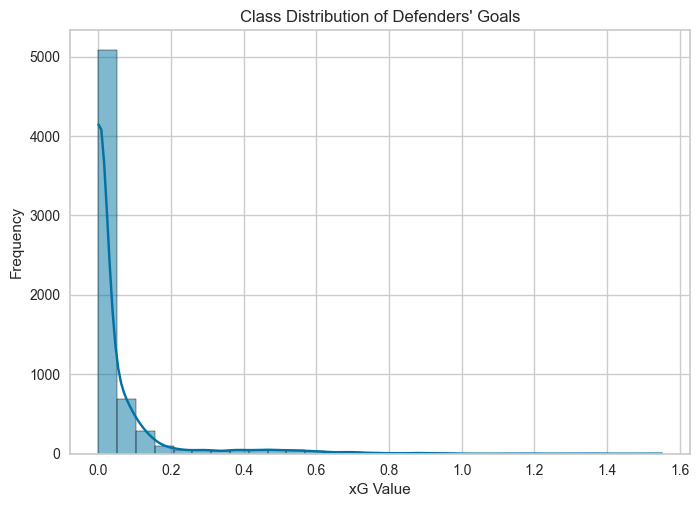

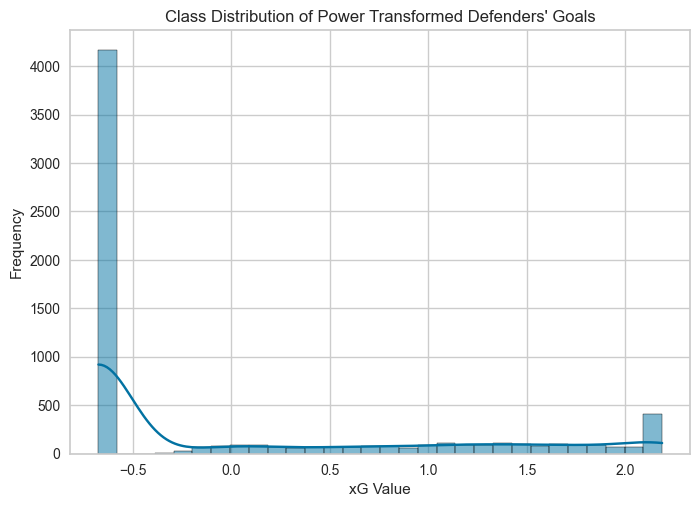

In [87]:

def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Power Transformed Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [88]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6037
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 87
[LightGBM] [Info] Start training from score 0.000613


,Description,Value
0,Session id,1919
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3182,0.2889,0.5372,0.7111,0.2451,2.1282,2.6980
rf,Random Forest Regressor,0.3195,0.2939,0.5418,0.7060,0.2436,2.1270,5.8030
lightgbm,Light Gradient Boosting Machine,0.3310,0.3010,0.5481,0.6991,0.2472,1.9563,2.0130
gbr,Gradient Boosting Regressor,0.3390,0.2989,0.5464,0.7013,0.2506,1.9812,2.7810
xgboost,Extreme Gradient Boosting,0.3575,0.3281,0.5724,0.6719,0.2521,2.0849,2.0200
ada,AdaBoost Regressor,0.3700,0.3240,0.5690,0.6761,0.2398,2.1613,1.5890
dt,Decision Tree Regressor,0.3929,0.5786,0.7602,0.4207,0.2675,2.4224,1.0630
huber,Huber Regressor,0.4419,0.5037,0.7089,0.4973,0.3273,1.3841,1.4710
knn,K Neighbors Regressor,0.4661,0.5047,0.7099,0.4955,0.3121,1.6713,1.2780
lr,Linear Regression,0.5095,0.4649,0.6813,0.5359,0.3520,1.3875,3.4170


ExtraTreesRegressor(n_jobs=-1, random_state=1919)

In [89]:
evaluate_model(base_def_xg_best)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

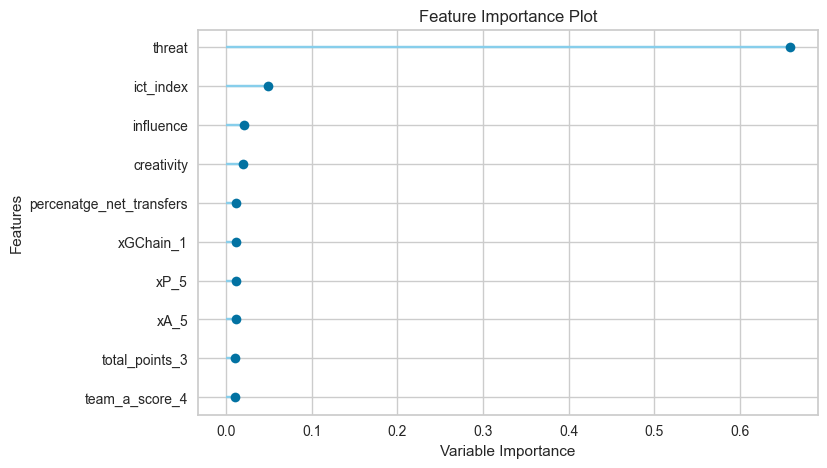

In [90]:
# plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
# plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Tune Model


In [91]:
def_xg_tuned = tune_model(base_def_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3201,0.3487,0.5905,0.6532,0.2569,1.5084
1,0.3502,0.4169,0.6457,0.5842,0.2584,2.2107
2,0.3317,0.3959,0.6292,0.6189,0.2676,1.6209
3,0.3485,0.4024,0.6343,0.5882,0.2603,6.2438
4,0.3227,0.3955,0.6289,0.6046,0.2532,0.6520
5,0.3475,0.3988,0.6315,0.6178,0.2716,1.1366
6,0.2926,0.3314,0.5757,0.6384,0.2369,1.5646
7,0.3311,0.4095,0.6399,0.6060,0.2576,2.0876
8,0.3291,0.3404,0.5834,0.6627,0.2481,1.2126


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [92]:
# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [93]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    2501
0.761169      11
0.761169       3
0.052510       2
0.423129       1
            ... 
0.103368       1
0.078944       1
0.051074       1
0.104148       1
0.036180       1
Name: count, Length: 4563, dtype: int64


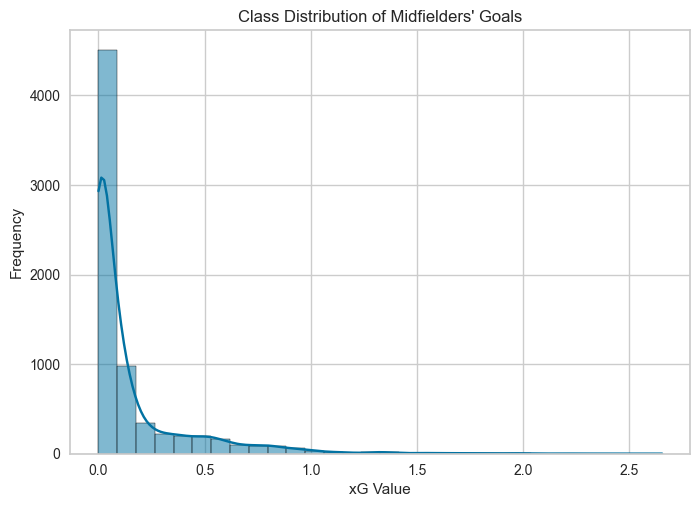

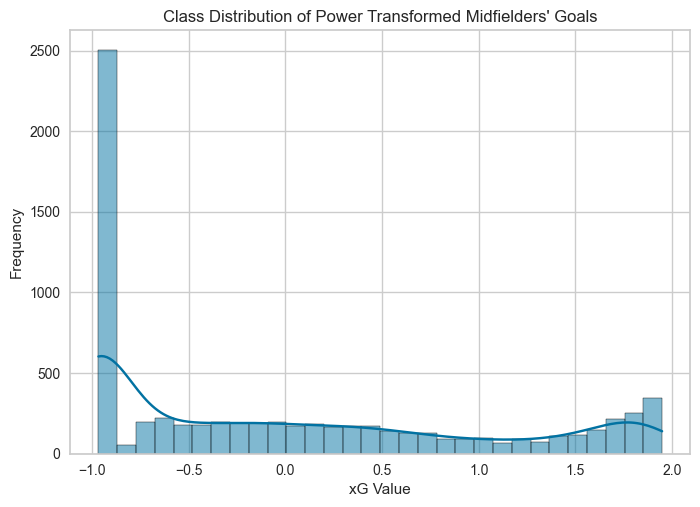

In [94]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Power Transformed Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [95]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE')
base_mid_xg_best

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016660 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7457
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 83
[LightGBM] [Info] Start training from score 0.004566


,Description,Value
0,Session id,3462
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3622,0.2768,0.5259,0.7237,0.2610,25.8884,13.7910
et,Extra Trees Regressor,0.3680,0.2799,0.5288,0.7207,0.2607,31.3679,5.3670
lightgbm,Light Gradient Boosting Machine,0.3684,0.2764,0.5255,0.7242,0.2588,25.4026,4.5110
gbr,Gradient Boosting Regressor,0.3702,0.2726,0.5219,0.7280,0.2587,29.3269,4.1600
xgboost,Extreme Gradient Boosting,0.3946,0.3078,0.5543,0.6928,0.2680,19.8374,4.4730
ada,AdaBoost Regressor,0.4382,0.3112,0.5575,0.6895,0.2824,30.4928,1.9490
knn,K Neighbors Regressor,0.4600,0.3931,0.6268,0.6078,0.2927,34.8077,6.1040
huber,Huber Regressor,0.4623,0.4097,0.6396,0.5915,0.2918,25.9407,2.4380
dt,Decision Tree Regressor,0.4710,0.5322,0.7291,0.4695,0.3093,15.6372,7.6670
lr,Linear Regression,0.4814,0.3841,0.6196,0.6171,0.3044,21.3120,2.8100


RandomForestRegressor(n_jobs=-1, random_state=3462)

In [96]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

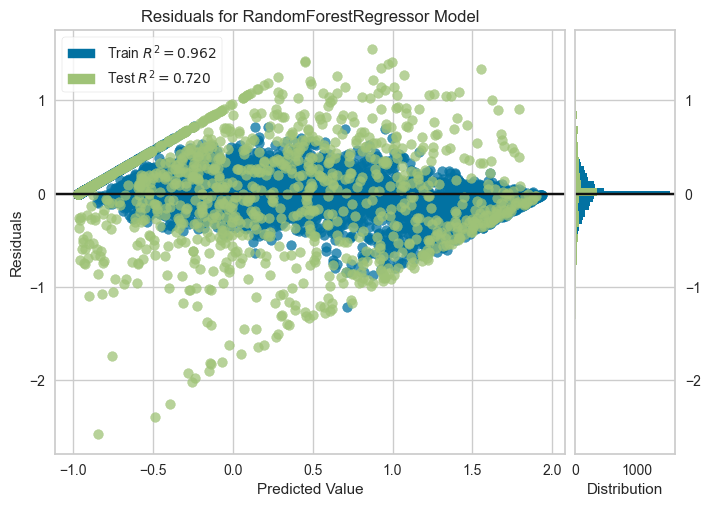

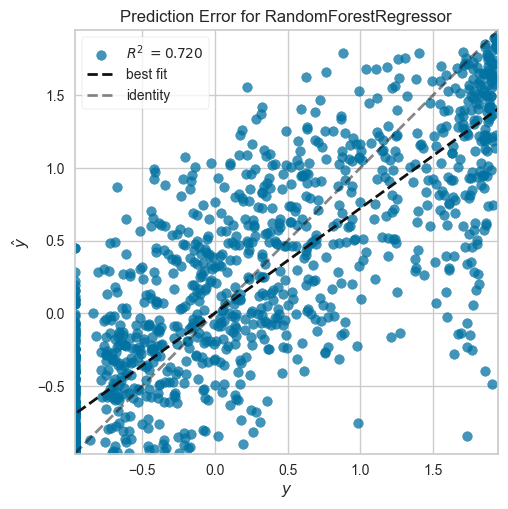

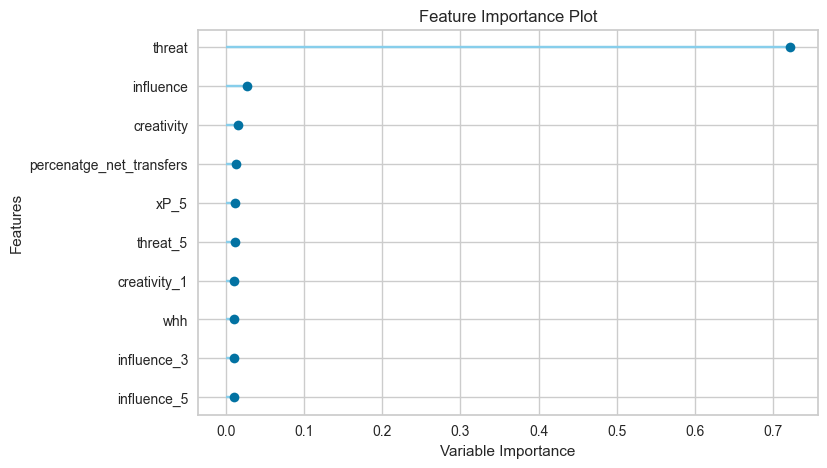

In [97]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Tune Model


In [98]:
mid_xg_tuned = tune_model(base_mid_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3641,0.2746,0.5240,0.7259,0.2549,271.7087
1,0.3432,0.2661,0.5159,0.7464,0.2510,0.8644
2,0.3555,0.2530,0.5030,0.7569,0.2573,2.8677
3,0.3356,0.2503,0.5003,0.7504,0.2512,1.5447
4,0.3695,0.2860,0.5348,0.7028,0.2788,1.3935
5,0.3499,0.2594,0.5093,0.7504,0.2611,2.0229
6,0.3638,0.2744,0.5238,0.7231,0.2692,1.3629
7,0.3530,0.2672,0.5169,0.7255,0.2492,1.7915
8,0.3727,0.2863,0.5351,0.7021,0.2532,1.6343


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [99]:
mid_xg_final_model = finalize_model(base_mid_xg_best)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## For


xG
0.000000    290
0.761169      7
0.208655      1
0.582700      1
0.366415      1
           ... 
0.583476      1
0.125661      1
1.442925      1
0.616388      1
0.326243      1
Name: count, Length: 1295, dtype: int64


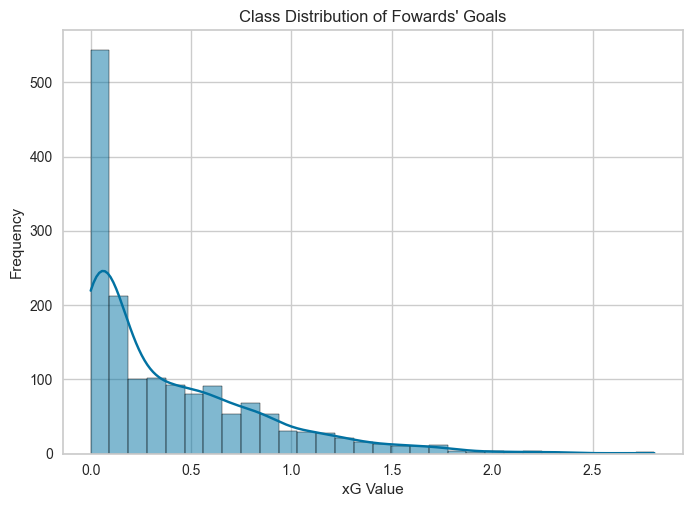

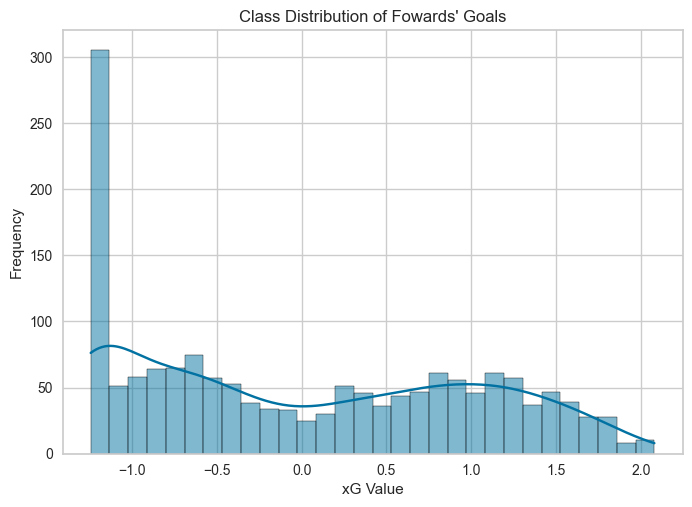

In [100]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6292
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.008673


,Description,Value
0,Session id,4297
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4486,0.3389,0.5800,0.6650,0.2723,1.2462,0.6450
rf,Random Forest Regressor,0.4496,0.3434,0.5841,0.6606,0.2776,1.2764,1.5850
et,Extra Trees Regressor,0.4566,0.3451,0.5857,0.6594,0.2828,1.2074,0.9970
lightgbm,Light Gradient Boosting Machine,0.4638,0.3671,0.6035,0.6376,0.2767,1.4798,0.5020
xgboost,Extreme Gradient Boosting,0.4711,0.3799,0.6151,0.6244,0.2741,1.3522,1.1170
knn,K Neighbors Regressor,0.5021,0.4322,0.6537,0.5731,0.2863,1.2373,1.0470
huber,Huber Regressor,0.5131,0.4267,0.6519,0.5780,0.2873,1.3428,0.8240
ridge,Ridge Regression,0.5209,0.4010,0.6318,0.6040,0.2991,1.2104,1.0590
lr,Linear Regression,0.5210,0.4015,0.6322,0.6034,0.2990,1.2109,0.8620
br,Bayesian Ridge,0.5231,0.4032,0.6337,0.6017,0.3004,1.1765,0.5600


GradientBoostingRegressor(random_state=4297)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


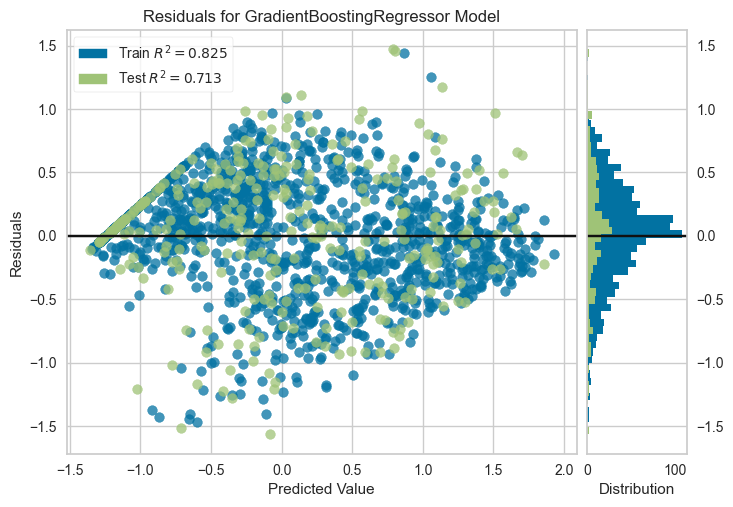

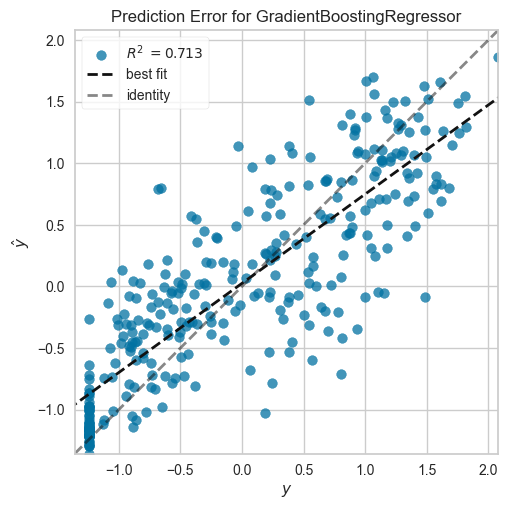

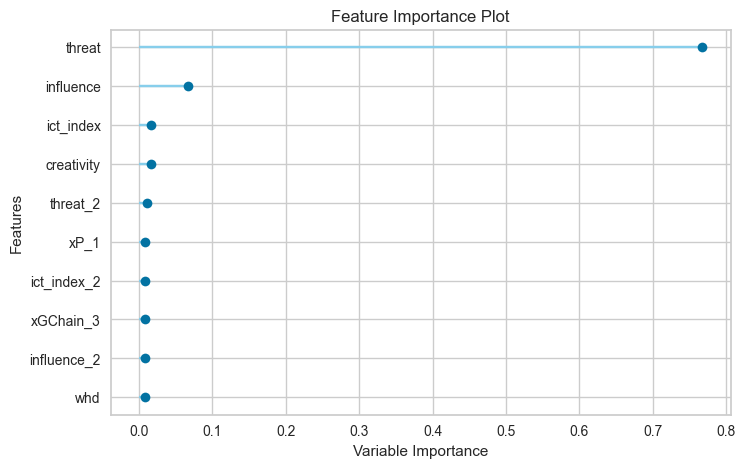

In [101]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Tune Model


In [102]:
tuned_fwd_xg_model = tune_model(base_fwd_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5083,0.4492,0.6702,0.5539,0.2835,2.0401
1,0.4628,0.3405,0.5835,0.6771,0.3076,1.0281
2,0.4372,0.3569,0.5974,0.6311,0.2560,0.8389
3,0.5294,0.4300,0.6558,0.6137,0.2961,1.3932
4,0.4494,0.3196,0.5653,0.6654,0.2844,2.9791
5,0.5025,0.4209,0.6488,0.5415,0.2728,1.2272
6,0.5163,0.4473,0.6688,0.5374,0.2706,1.8231
7,0.4978,0.4102,0.6405,0.6176,0.2653,0.7950
8,0.4860,0.3611,0.6009,0.6412,0.3103,0.9843


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [103]:
fwd_xg_final_model = finalize_model(tuned_fwd_xg_model)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [104]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2',
            'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    4470
0.059942       2
0.063347       1
0.108050       1
0.049833       1
            ... 
0.016065       1
0.037171       1
0.023500       1
0.013137       1
0.549479       1
Name: count, Length: 2103, dtype: int64


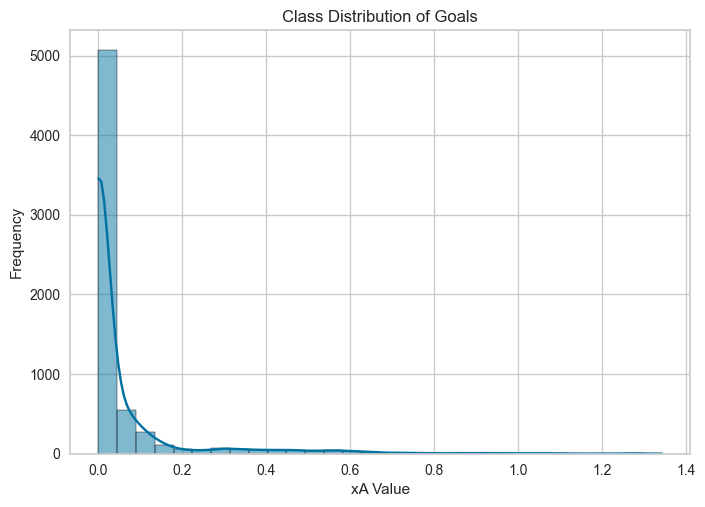

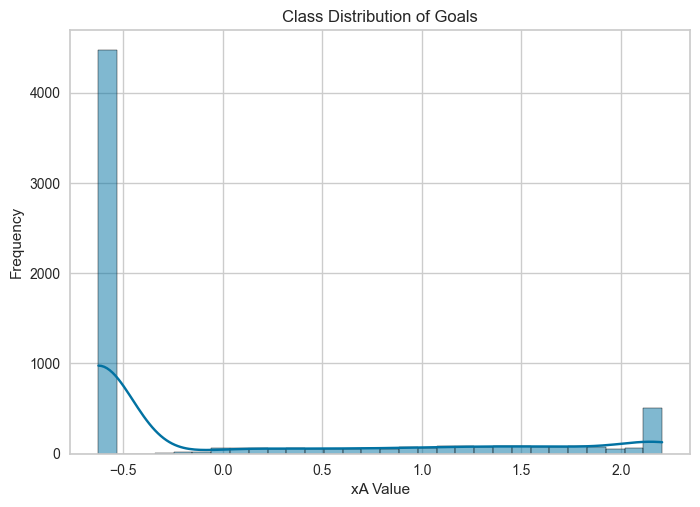

In [105]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6233
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 79
[LightGBM] [Info] Start training from score 0.005754


,Description,Value
0,Session id,8148
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1989,0.1786,0.4215,0.8215,0.1874,0.9423,5.5290
et,Extra Trees Regressor,0.2021,0.1763,0.4186,0.8238,0.1867,0.9135,1.6000
gbr,Gradient Boosting Regressor,0.2056,0.1743,0.4164,0.8256,0.1854,0.9496,2.0630
lightgbm,Light Gradient Boosting Machine,0.2088,0.1821,0.4258,0.8174,0.1923,0.9480,1.0000
ada,AdaBoost Regressor,0.2094,0.1825,0.4256,0.8181,0.1870,0.9236,1.0440
xgboost,Extreme Gradient Boosting,0.2283,0.2051,0.4516,0.7950,0.2019,0.9948,1.1540
knn,K Neighbors Regressor,0.2569,0.2638,0.5124,0.7351,0.2345,0.8364,0.5430
dt,Decision Tree Regressor,0.2598,0.3408,0.5828,0.6594,0.2505,1.0909,0.6040
huber,Huber Regressor,0.3432,0.3982,0.6296,0.6012,0.2842,0.5898,0.5390
lr,Linear Regression,0.4038,0.3740,0.6105,0.6257,0.2927,0.7180,0.4210


RandomForestRegressor(n_jobs=-1, random_state=8148)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


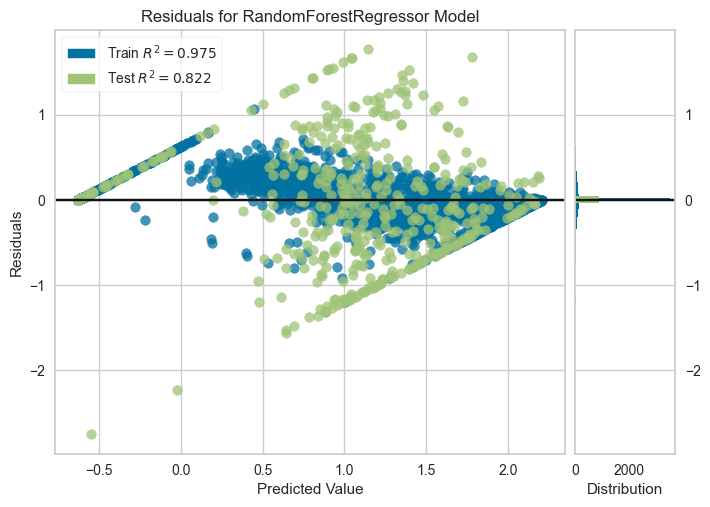

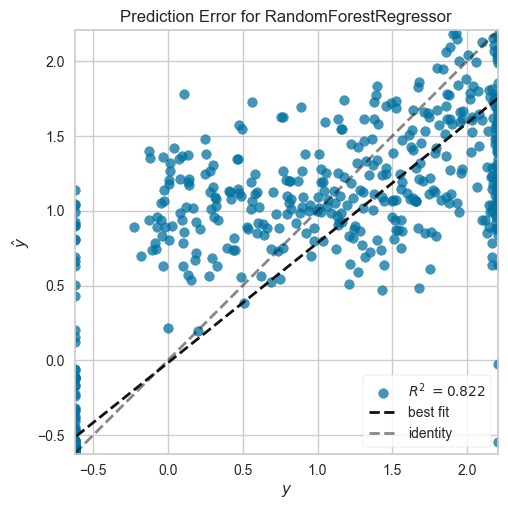

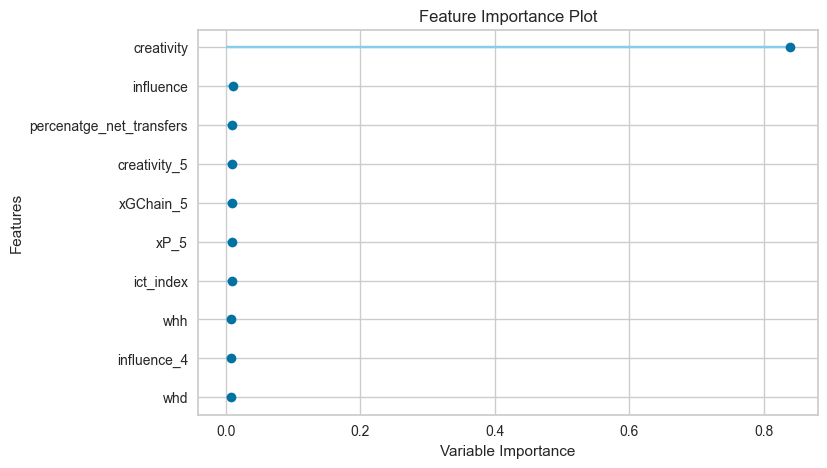

In [106]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Tune Model


In [107]:
def_xa_tuned = tune_model(base_def_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1918,0.1833,0.4281,0.8128,0.1916,0.9320
1,0.2174,0.2128,0.4613,0.7878,0.2090,0.7450
2,0.1926,0.1961,0.4429,0.8067,0.2014,0.9588
3,0.2112,0.2017,0.4491,0.8147,0.1977,0.7193
4,0.1770,0.1585,0.3982,0.8536,0.1854,1.2281
5,0.2121,0.2303,0.4799,0.7891,0.1778,0.4186
6,0.1812,0.1593,0.3991,0.8238,0.1873,1.1796
7,0.2132,0.2179,0.4668,0.7961,0.2042,1.1626
8,0.1509,0.1451,0.3809,0.8294,0.1686,0.4122


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [108]:
def_xa_final_model = finalize_model(base_def_xa_best)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## Mid


xA
0.000000    2859
0.107738       2
0.095407       1
0.023504       1
0.403232       1
            ... 
0.454983       1
0.081762       1
0.106337       1
0.115025       1
0.043413       1
Name: count, Length: 4217, dtype: int64


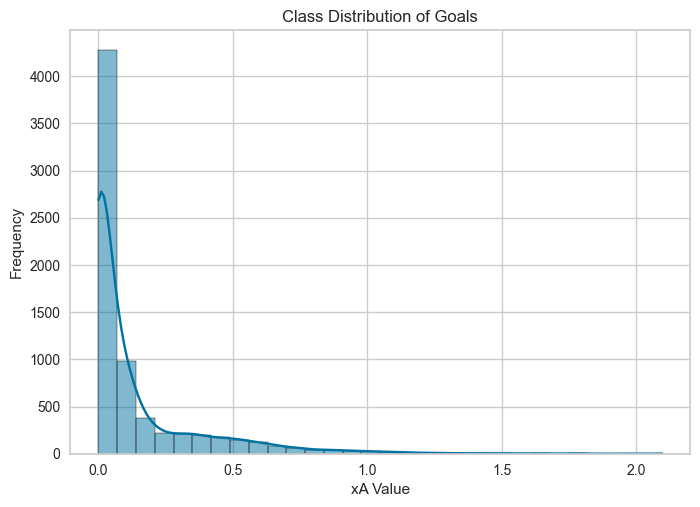

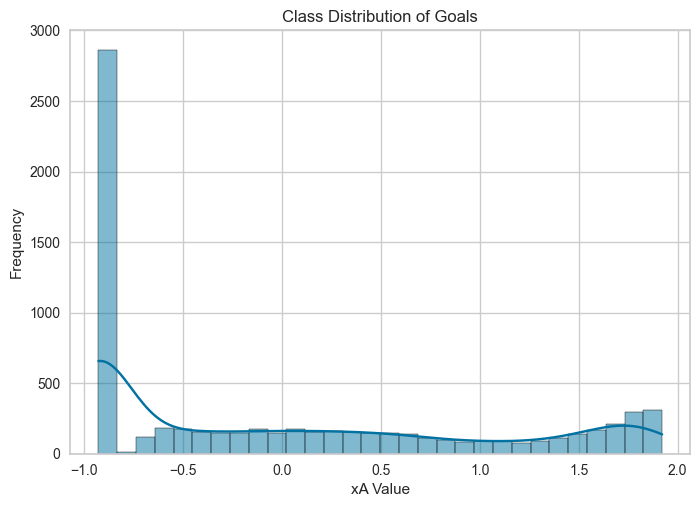

In [109]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7538
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 78
[LightGBM] [Info] Start training from score 0.001234


,Description,Value
0,Session id,3562
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3508,0.3017,0.5487,0.6985,0.2661,1.4909,5.4780
et,Extra Trees Regressor,0.3573,0.3026,0.5494,0.6976,0.2681,1.4355,2.2610
gbr,Gradient Boosting Regressor,0.3577,0.2936,0.5411,0.7065,0.2751,1.3688,1.8570
lightgbm,Light Gradient Boosting Machine,0.3578,0.3008,0.5478,0.6994,0.2673,1.4050,1.3910
ada,AdaBoost Regressor,0.3861,0.3183,0.5636,0.6815,0.2461,1.7256,0.8400
xgboost,Extreme Gradient Boosting,0.3932,0.3380,0.5809,0.6619,0.2732,1.6018,1.0310
knn,K Neighbors Regressor,0.4309,0.4110,0.6400,0.5888,0.2913,1.7158,0.6850
huber,Huber Regressor,0.4363,0.4268,0.6516,0.5745,0.2997,1.2443,0.6020
dt,Decision Tree Regressor,0.4516,0.5643,0.7505,0.4359,0.3098,2.2043,0.8230
lr,Linear Regression,0.4713,0.4041,0.6343,0.5969,0.3146,1.1955,0.7610


RandomForestRegressor(n_jobs=-1, random_state=3562)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


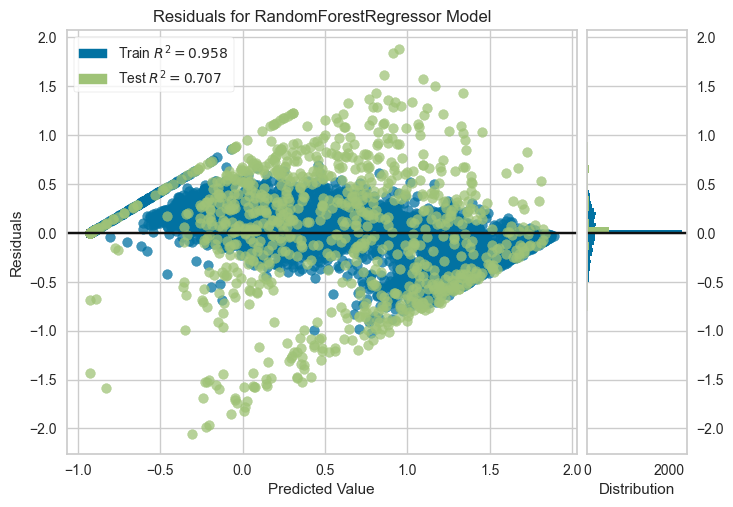

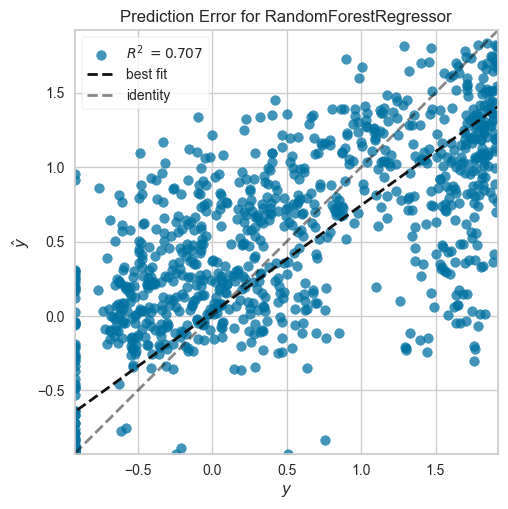

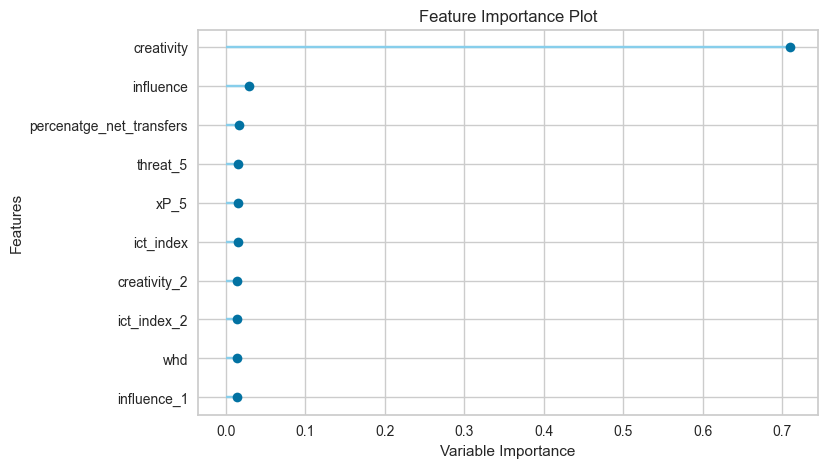

In [110]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Tune model


In [111]:
mid_xa_tuned = tune_model(base_mid_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3905,0.4051,0.6365,0.6098,0.2894,1.6145
1,0.3512,0.3477,0.5896,0.6336,0.2804,1.1195
2,0.3697,0.3606,0.6005,0.6522,0.2889,1.7445
3,0.3845,0.4325,0.6577,0.5870,0.3093,1.3505
4,0.3418,0.3276,0.5723,0.6575,0.2862,1.8017
5,0.3386,0.3305,0.5749,0.6254,0.2602,1.4043
6,0.3346,0.3536,0.5946,0.6529,0.2598,0.9902
7,0.3482,0.3915,0.6257,0.5950,0.2892,0.8969
8,0.3335,0.3162,0.5623,0.6879,0.2605,1.1532


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [112]:
mid_xa_final_model = finalize_model(base_mid_xa_best)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## For


xA
0.000000    767
0.127663      1
0.077458      1
0.147103      1
0.733360      1
           ... 
0.414716      1
0.122116      1
0.031267      1
0.401950      1
0.048869      1
Name: count, Length: 824, dtype: int64


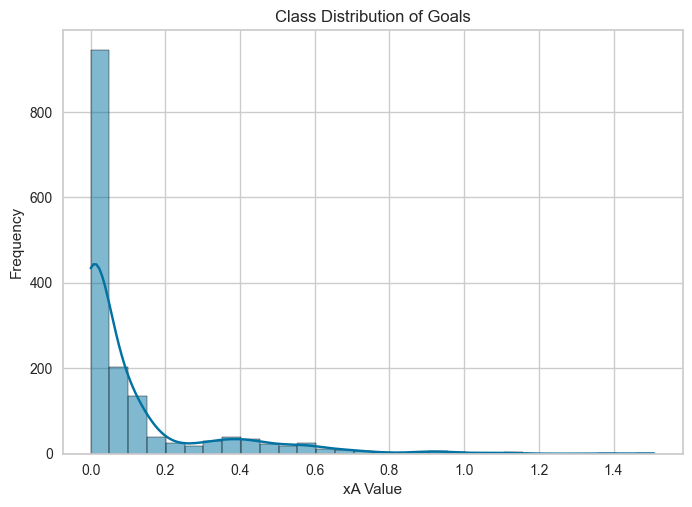

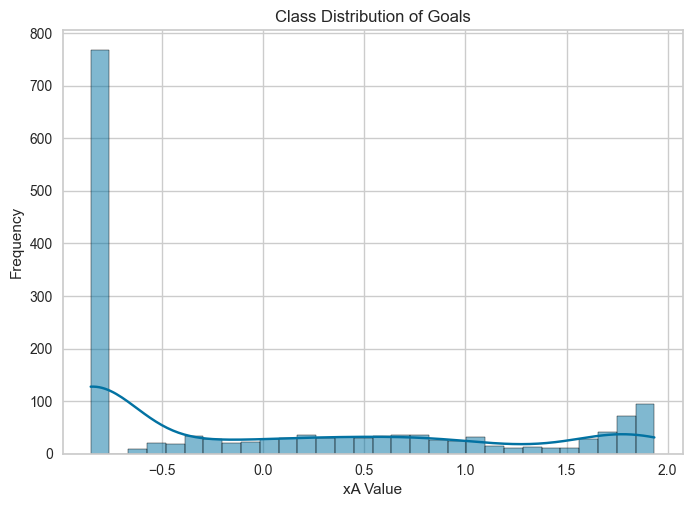

In [113]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7086
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 81
[LightGBM] [Info] Start training from score 0.004888
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Description,Value
0,Session id,2044
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3044,0.2630,0.5120,0.7324,0.2363,1.0631,3.0400
et,Extra Trees Regressor,0.3072,0.2544,0.5036,0.7413,0.2322,1.0761,2.5740
gbr,Gradient Boosting Regressor,0.3262,0.2616,0.5105,0.7343,0.2359,1.0891,2.7710
lightgbm,Light Gradient Boosting Machine,0.3427,0.2888,0.5367,0.7061,0.2516,1.1582,2.5490
xgboost,Extreme Gradient Boosting,0.3524,0.3193,0.5645,0.6751,0.2618,1.1948,2.0190
dt,Decision Tree Regressor,0.3964,0.4805,0.6917,0.5106,0.2994,1.7010,1.4070
huber,Huber Regressor,0.4021,0.3613,0.5997,0.6327,0.2975,0.8495,1.8850
ada,AdaBoost Regressor,0.4054,0.2984,0.5455,0.6962,0.2406,1.3825,2.0380
br,Bayesian Ridge,0.4204,0.3439,0.5856,0.6501,0.3008,0.8841,1.5170
ridge,Ridge Regression,0.4218,0.3462,0.5876,0.6475,0.2990,0.8955,1.5060


RandomForestRegressor(n_jobs=-1, random_state=2044)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


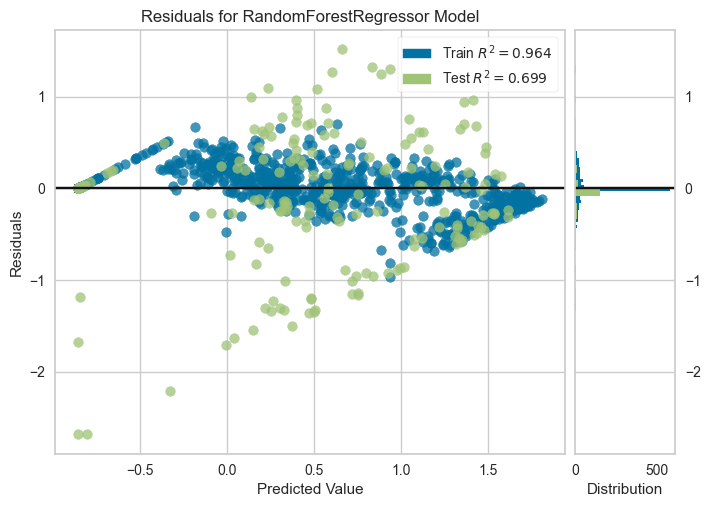

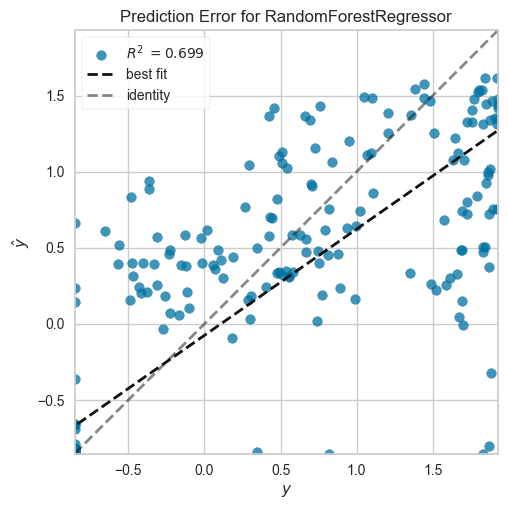

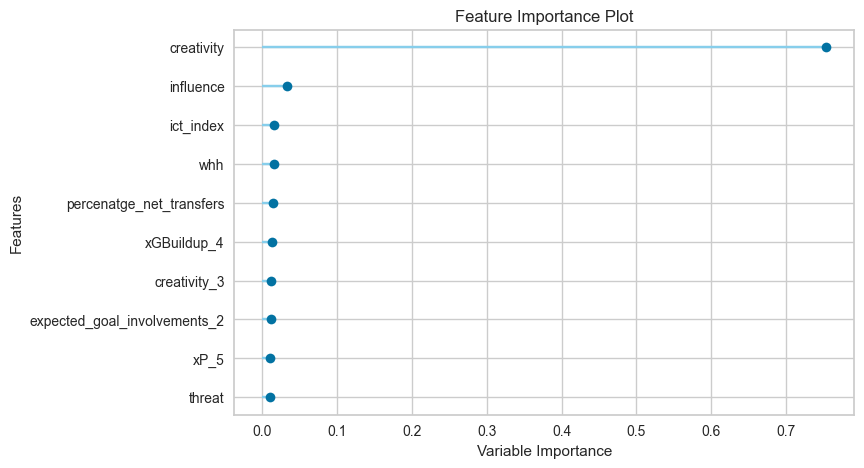

In [114]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Tune model


In [115]:
fwd_xa_tuned = tune_model(base_fwd_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2763,0.2923,0.5407,0.6729,0.2500,0.6087
1,0.2905,0.2746,0.5240,0.7159,0.2519,0.9610
2,0.3275,0.3131,0.5596,0.6709,0.2489,1.3400
3,0.2751,0.2381,0.4879,0.7591,0.2521,1.5729
4,0.2979,0.3193,0.5651,0.7156,0.2549,0.8282
5,0.2887,0.2802,0.5294,0.7146,0.2289,1.0975
6,0.2793,0.2338,0.4836,0.7608,0.2417,1.0650
7,0.3271,0.3132,0.5596,0.6567,0.2580,0.7254
8,0.3177,0.2609,0.5108,0.7350,0.2250,0.7811


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [116]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     360
3     298
1     255
4     235
5     156
0     126
6      84
7      54
8      21
9      15
10      4
11      2
12      1
13      1
Name: count, dtype: int64


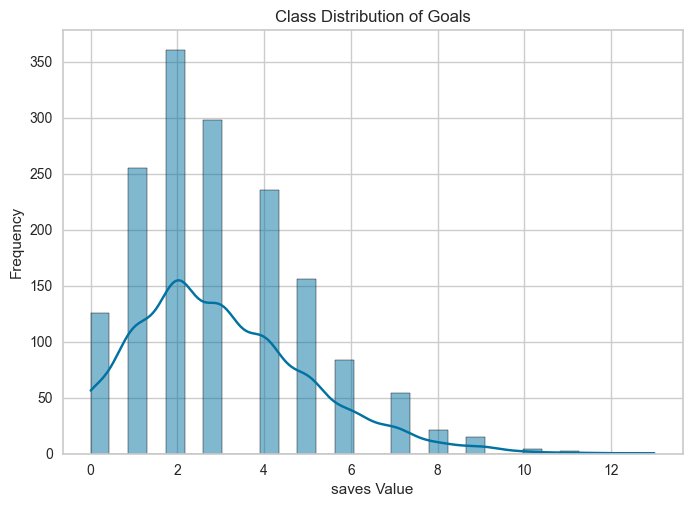

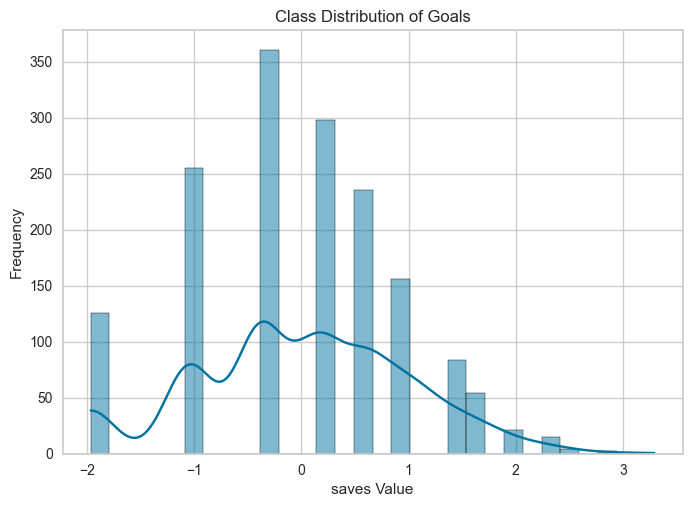

In [117]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.025734 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2995
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 66
[LightGBM] [Info] Start training from score -0.000743


,Description,Value
0,Session id,3207
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2701,0.1391,0.3711,0.8591,0.1850,0.6267,1.9810
rf,Random Forest Regressor,0.2746,0.1470,0.3812,0.8512,0.1896,0.6319,2.4330
et,Extra Trees Regressor,0.2769,0.1463,0.3796,0.8519,0.1908,0.6394,2.0480
lightgbm,Light Gradient Boosting Machine,0.2835,0.1521,0.3880,0.8455,0.1944,0.6607,2.1590
xgboost,Extreme Gradient Boosting,0.2982,0.1668,0.4060,0.8314,0.2025,0.6819,1.6510
omp,Orthogonal Matching Pursuit,0.3090,0.1748,0.4157,0.8232,0.2000,0.6740,0.9180
br,Bayesian Ridge,0.3097,0.1747,0.4156,0.8232,0.2009,0.6772,0.9720
ridge,Ridge Regression,0.3116,0.1752,0.4163,0.8227,0.2029,0.6821,0.8510
lr,Linear Regression,0.3118,0.1754,0.4165,0.8225,0.2029,0.6823,1.3440
en,Elastic Net,0.3124,0.1761,0.4173,0.8221,0.2026,0.6638,1.0300


GradientBoostingRegressor(random_state=3207)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


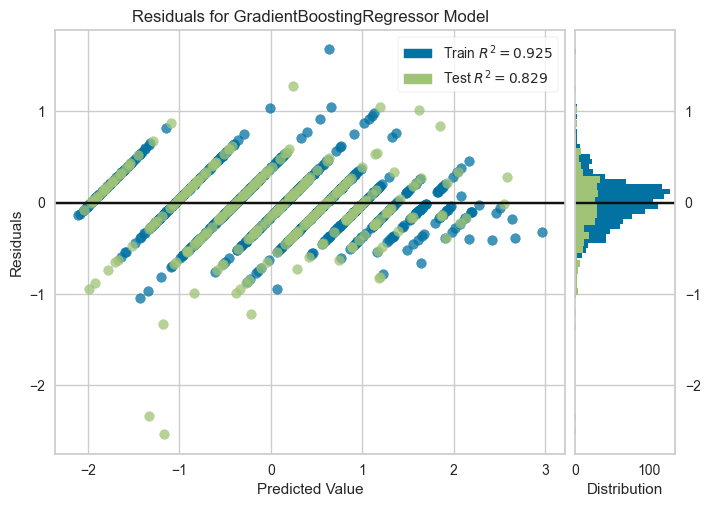

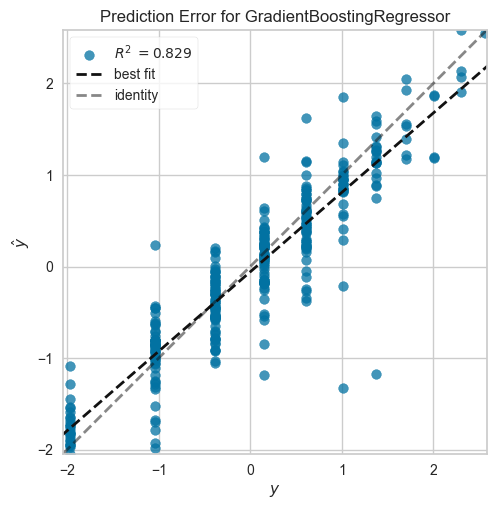

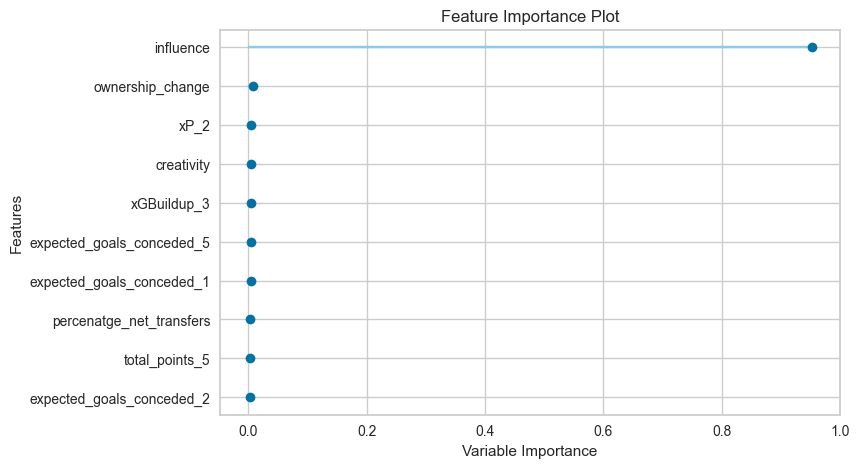

In [118]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Tune Model


In [119]:
g_saves_tuned = tune_model(base_g_saves_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3117,0.1759,0.4194,0.8068,0.2045,0.7209
1,0.3021,0.1611,0.4013,0.8677,0.2101,0.7596
2,0.2785,0.1400,0.3741,0.8399,0.1898,0.7618
3,0.3051,0.1496,0.3867,0.8739,0.2027,0.6114
4,0.3487,0.2367,0.4865,0.8153,0.2377,0.7578
5,0.3251,0.2071,0.4551,0.7589,0.2397,0.7467
6,0.3191,0.1921,0.4383,0.7775,0.2190,0.7363
7,0.2823,0.1284,0.3584,0.8512,0.1982,0.6386
8,0.2966,0.1537,0.3921,0.8468,0.1998,0.6034


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [120]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [121]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.48    19
0.83    17
1.03    14
1.32    13
1.12    13
        ..
3.22     1
2.62     1
3.52     1
3.70     1
3.60     1
Name: count, Length: 344, dtype: int64


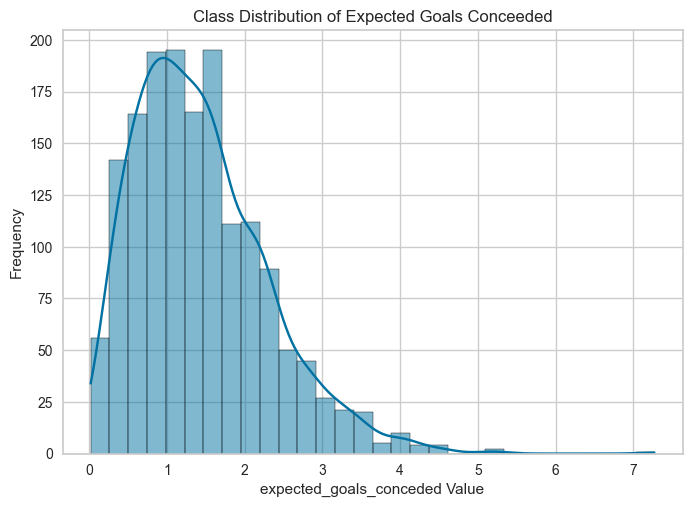

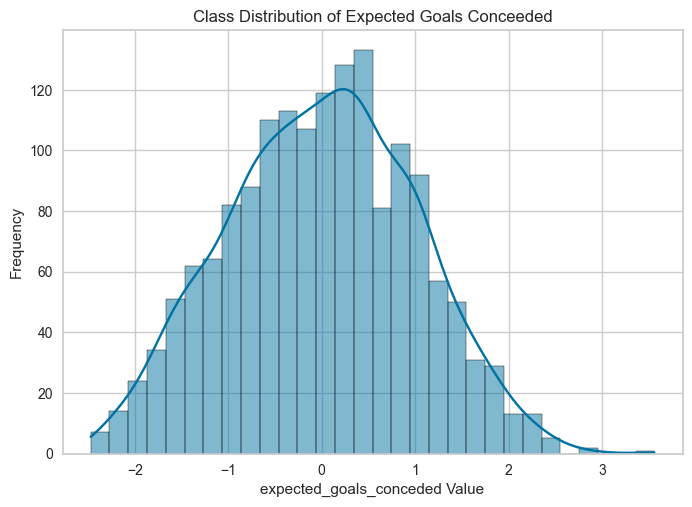

In [122]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002911 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3466
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 65
[LightGBM] [Info] Start training from score -0.016965


,Description,Value
0,Session id,6363
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.7052,0.7564,0.8691,0.2328,0.4110,2.0112,2.0910
ridge,Ridge Regression,0.7057,0.7469,0.8630,0.2429,0.4001,1.8253,1.3440
lr,Linear Regression,0.7060,0.7480,0.8636,0.2418,0.3996,1.8380,1.2800
lar,Least Angle Regression,0.7110,0.7617,0.8713,0.2279,0.4005,1.8814,1.0930
br,Bayesian Ridge,0.7118,0.7536,0.8669,0.2357,0.4072,1.8298,0.4460
et,Extra Trees Regressor,0.7122,0.7655,0.8739,0.2240,0.4052,1.9318,1.5600
gbr,Gradient Boosting Regressor,0.7164,0.7715,0.8770,0.2178,0.4143,2.0270,0.9990
ada,AdaBoost Regressor,0.7173,0.7710,0.8772,0.2184,0.4369,1.6177,0.8390
en,Elastic Net,0.7249,0.7774,0.8808,0.2117,0.4224,1.8671,1.5900
omp,Orthogonal Matching Pursuit,0.7265,0.7832,0.8841,0.2057,0.4167,1.9452,0.7090


RandomForestRegressor(n_jobs=-1, random_state=6363)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


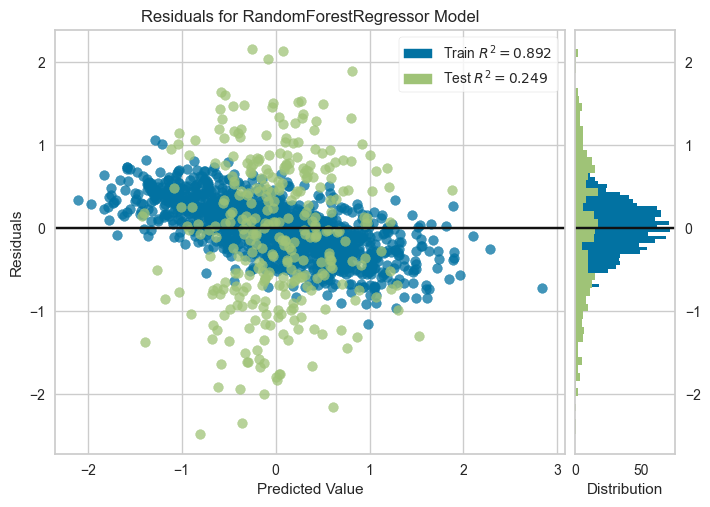

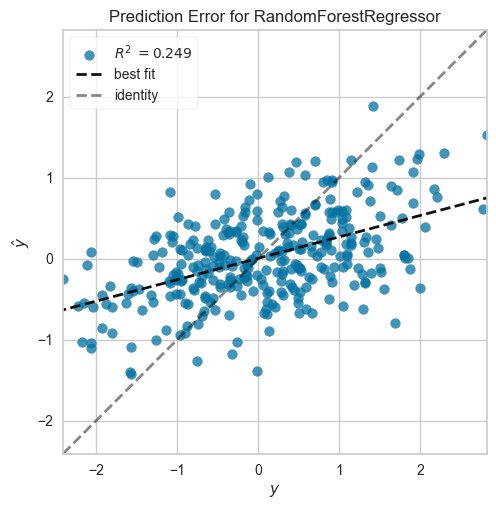

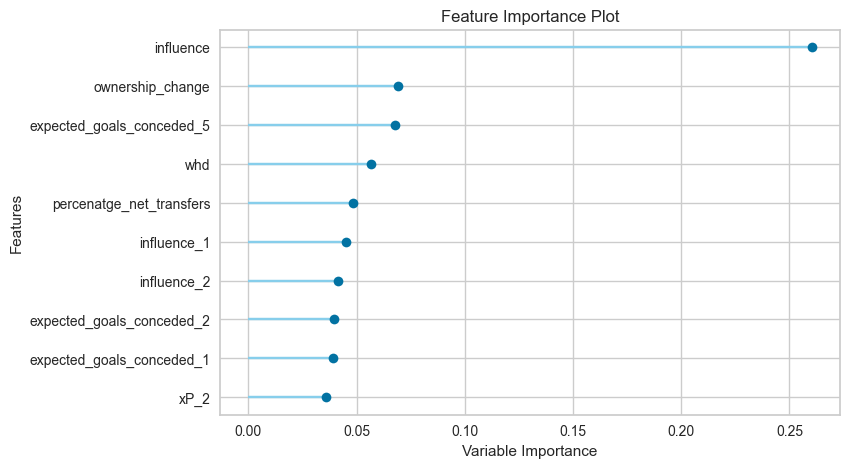

In [123]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [124]:
g_xgc_tuned = tune_model(base_g_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7081,0.7324,0.8558,0.2163,0.4492,1.2358
1,0.6682,0.7150,0.8456,0.2237,0.4321,2.1608
2,0.6845,0.6802,0.8248,0.2586,0.4298,1.4247
3,0.6996,0.7469,0.8642,0.2437,0.4366,1.4653
4,0.7495,0.7922,0.8901,0.1752,0.4362,2.6463
5,0.8025,0.9286,0.9636,0.1516,0.4694,1.1402
6,0.7106,0.7434,0.8622,0.2038,0.4139,1.0749
7,0.6786,0.7133,0.8446,0.3236,0.4496,1.1550
8,0.6904,0.7555,0.8692,0.2767,0.4330,2.5143


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [125]:
g_xgc_final_model = finalize_model(g_xgc_tuned)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Def


expected_goals_conceded
0.00    79
0.83    75
1.03    57
1.48    56
1.08    47
        ..
9.84     1
6.86     1
6.94     1
3.06     1
3.07     1
Name: count, Length: 386, dtype: int64


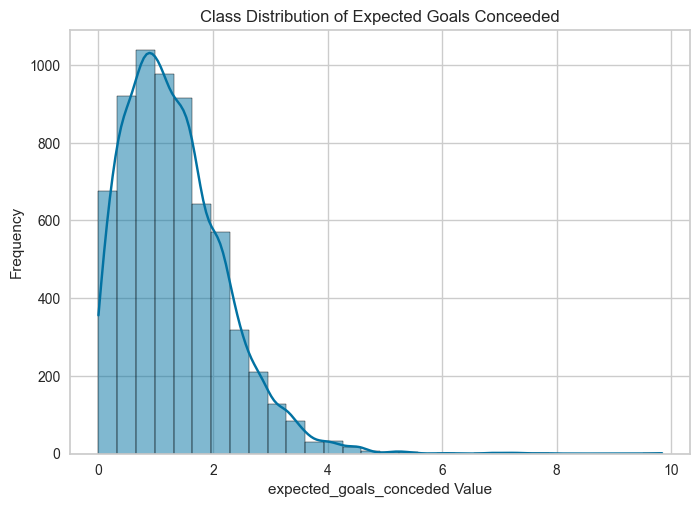

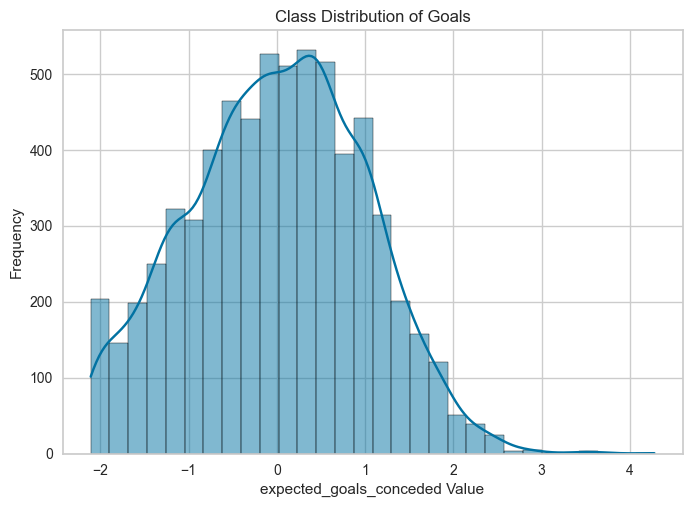

In [126]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.117132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6536
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 72
[LightGBM] [Info] Start training from score -0.001945


,Description,Value
0,Session id,7589
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6398,0.6559,0.8078,0.3383,0.3874,1.8926,3.6050
rf,Random Forest Regressor,0.6657,0.7011,0.8364,0.2918,0.4066,1.8110,7.8230
lightgbm,Light Gradient Boosting Machine,0.6705,0.7070,0.8403,0.2849,0.3964,2.0415,1.6080
xgboost,Extreme Gradient Boosting,0.6741,0.7332,0.8554,0.2594,0.3834,2.3569,1.6430
gbr,Gradient Boosting Regressor,0.6908,0.7364,0.8577,0.2550,0.4220,1.8627,2.9350
ada,AdaBoost Regressor,0.7522,0.8520,0.9228,0.1384,0.4852,1.5696,1.9140
lr,Linear Regression,0.7635,0.8797,0.9376,0.1103,0.4584,1.8707,1.1080
ridge,Ridge Regression,0.7636,0.8797,0.9377,0.1102,0.4585,1.8676,1.2400
br,Bayesian Ridge,0.7648,0.8812,0.9385,0.1087,0.4624,1.8504,0.9770
en,Elastic Net,0.7966,0.9484,0.9735,0.0413,0.5349,1.3541,1.1050


ExtraTreesRegressor(n_jobs=-1, random_state=7589)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


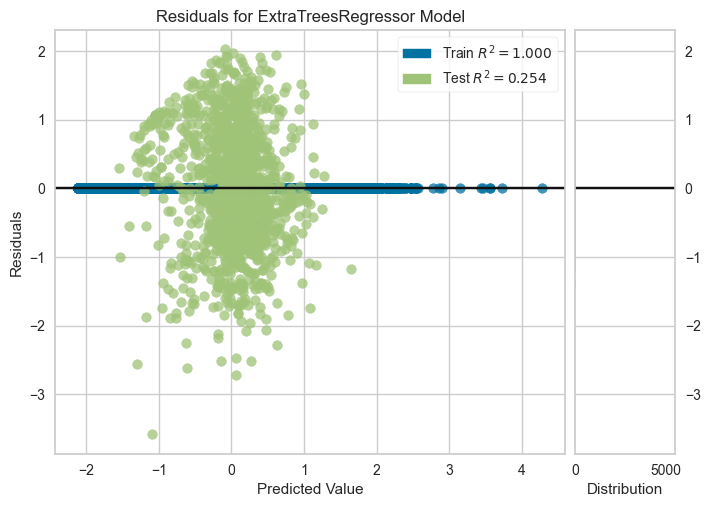

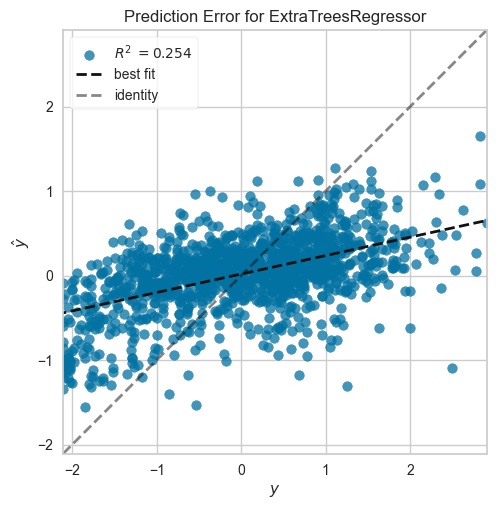

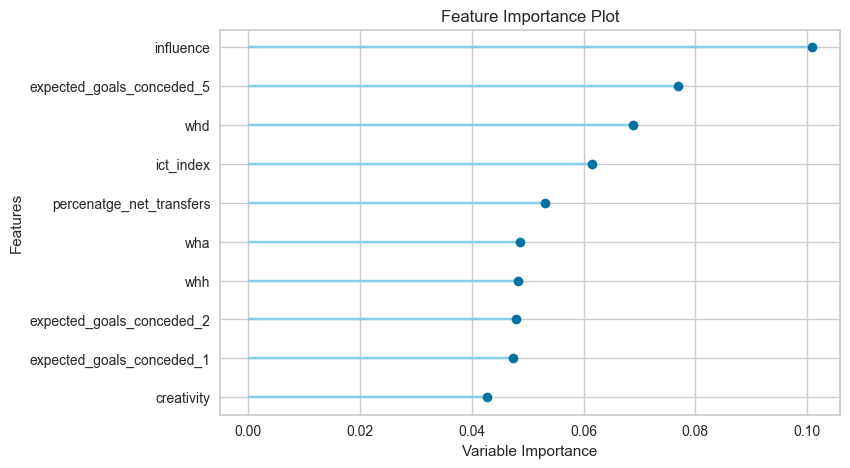

In [127]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [128]:
def_xgc_tuned = tune_model(base_def_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6822,0.7370,0.8585,0.1853,0.4076,1.7274
1,0.7547,0.8850,0.9408,0.1578,0.4931,1.3096
2,0.6929,0.7053,0.8398,0.2466,0.4332,1.7879
3,0.7534,0.8294,0.9107,0.2038,0.4942,1.2705
4,0.7383,0.8458,0.9197,0.1359,0.4840,2.5400
5,0.7035,0.7471,0.8644,0.2566,0.4331,1.1587
6,0.7155,0.7517,0.8670,0.2716,0.4380,1.6860
7,0.6741,0.7026,0.8382,0.2776,0.4190,1.7670
8,0.7068,0.7555,0.8692,0.2633,0.4479,1.9322


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [129]:
def_xgc_final_model = finalize_model(base_def_xgc_best)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 